In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# Load cleaned dataset
books_df = pd.read_csv(
    "../data/processed/books_cleaned.csv"
)

books_df.head()

,title,price,availability,rating,product_url,category,description,upc,tax,number_available,stock_quantity,stock_status,price_category
0,A Light in the Attic,51.77,In stock,3,http://books.toscrape.com/catalogue/a-light-in...,Poetry,It's hard to imagine a world without A Light i...,a897fe39b1053632,0.0,In stock (22 available),22.0,In Stock,High
1,Tipping the Velvet,53.74,In stock,1,http://books.toscrape.com/catalogue/tipping-th...,Historical Fiction,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0.0,In stock (20 available),20.0,In Stock,High
2,Soumission,50.10,In stock,1,http://books.toscrape.com/catalogue/soumission...,Fiction,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760,0.0,In stock (20 available),20.0,In Stock,High
3,Sharp Objects,47.82,In stock,4,http://books.toscrape.com/catalogue/sharp-obje...,Mystery,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0.0,In stock (20 available),20.0,In Stock,High
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,http://books.toscrape.com/catalogue/sapiens-a-...,History,From a renowned historian comes a groundbreaki...,4165285e1663650f,0.0,In stock (20 available),20.0,In Stock,High


In [ ]:
# Check missing values
books_df.isnull().sum()

In [6]:
# Check dataset shape
books_df.shape

(1000, 13)

In [7]:
# Top categories by number of books
category_counts = (
    books_df["category"]
    .value_counts()
    .head(10)
)

category_counts

category
Default           150
Nonfiction        110
Sequential Art     74
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            46
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

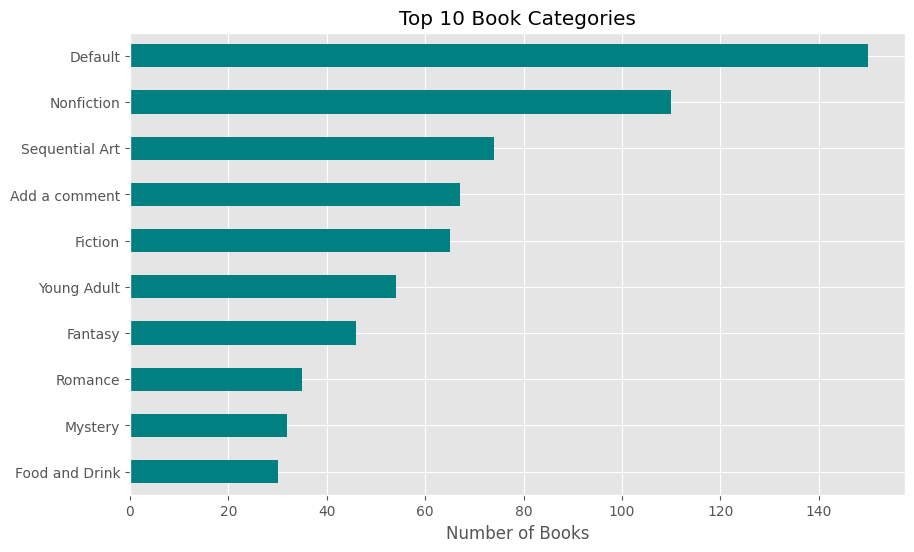

In [19]:
# Visualize top categories
plt.figure(figsize=(10,6))

category_counts.sort_values().plot(kind="barh", color="Teal")

plt.title("Top 10 Book Categories")

plt.xlabel("Number of Books")

plt.ylabel("")

plt.show()

In [20]:
# Rating distribution
books_df["rating"].value_counts()

rating
1    226
3    203
5    196
2    196
4    179
Name: count, dtype: int64

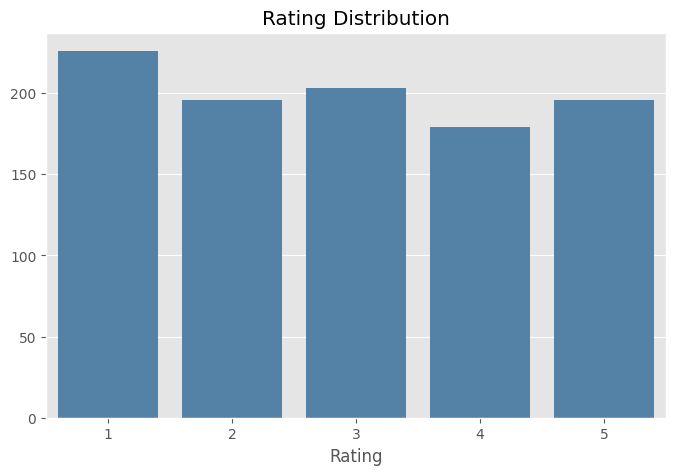

In [23]:
# Visualize ratings
plt.figure(figsize=(8,5))

sns.countplot(data=books_df, x="rating", color="steelblue")

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("")

plt.show()

In [29]:
# Average rating by category
avg_rating = (
    books_df
    .groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
).round(1)

avg_rating

category
Erotica              5.0
Adult Fiction        5.0
Novels               5.0
Christian Fiction    4.2
Art                  3.9
Health               3.8
Poetry               3.4
Humor                3.4
Spirituality         3.3
Young Adult          3.3
Name: rating, dtype: float64

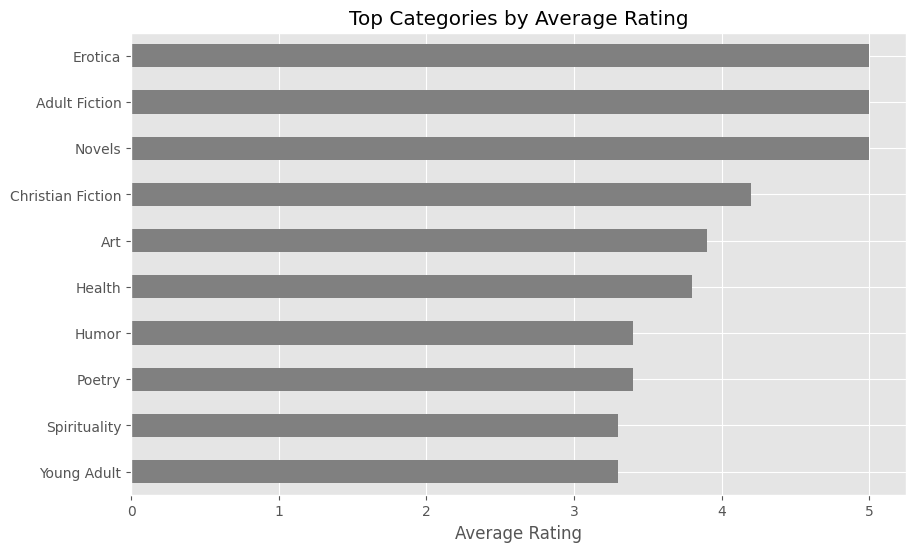

In [36]:
# Visualize average rating
plt.figure(figsize=(10,6))

avg_rating.sort_values().plot(kind="barh", color="gray")

plt.title("Top Categories by Average Rating")

plt.xlabel("Average Rating")

plt.ylabel("")

plt.show()

In [80]:
# Average rating by price category
avg_rating_by_price = (
books_df.groupby(
    "price_category"
)["rating"].mean()
).round(2)
avg_rating_by_price

price_category
High      2.98
Low       2.96
Medium    2.85
Name: rating, dtype: float64

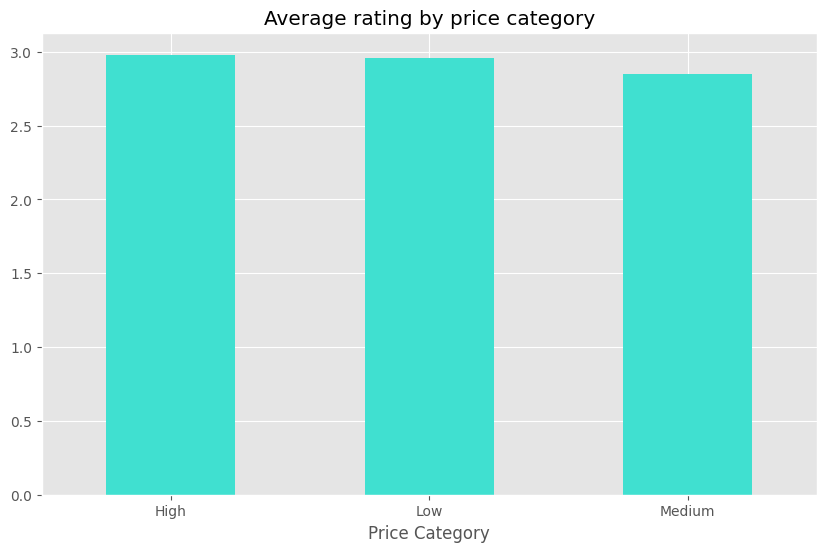

In [96]:
# Visualize average rating by price
plt.figure(figsize=(10,6))

avg_rating_by_price.plot(kind="bar", color="turquoise")

plt.title("Average rating by price category")

plt.xlabel("Price Category")

plt.ylabel("")

plt.xticks(rotation=0)

plt.show()

In [40]:
# Summary statistics
books_df["price"].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: price, dtype: float64

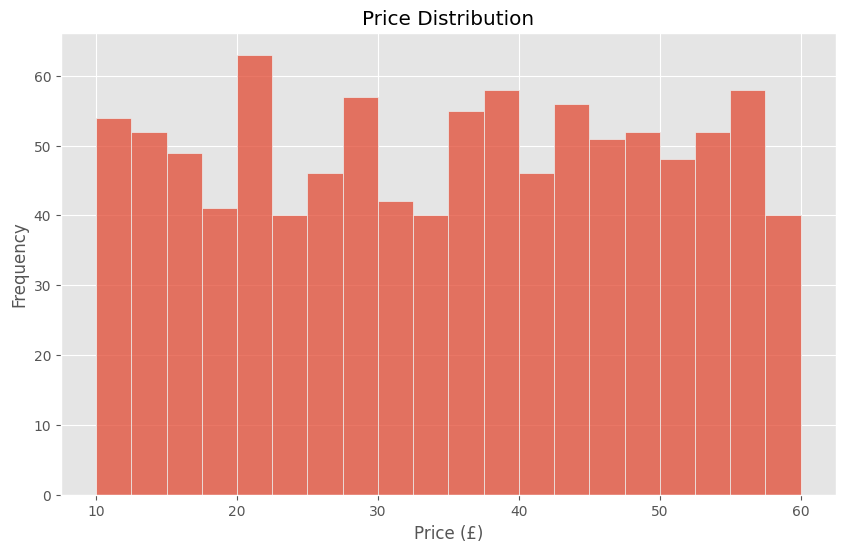

In [43]:
# Price distribution
plt.figure(figsize=(10,6))

sns.histplot(books_df["price"], bins=20)

plt.title("Price Distribution")

plt.xlabel("Price (£)")

plt.ylabel("Frequency")

plt.show()

In [90]:
# Most expensive books
expensive_books = (
books_df[
    ["title","price"]
].sort_values(
    by="price",
    ascending=False
).head(10)
)
expensive_books

,title,price
648,The Perfect Play (Play by Play #1),59.99
617,Last One Home (New Beginnings #1),59.98
860,Civilization and Its Discontents,59.95
560,The Barefoot Contessa Cookbook,59.92
366,The Diary of a Young Girl,59.90
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64
387,Boar Island (Anna Pigeon #19),59.48
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45
393,The Improbability of Love,59.45


The most expensive books in the dataset are all priced around £60, indicating limited variation among the highest-priced titles. This suggests the bookstore may have an upper pricing threshold for products.

In [48]:
# Average price by category
avg_price = (
    books_df
    .groupby("category")["price"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
).round(2)

avg_price

category
Suspense            58.33
Novels              54.81
Politics            53.61
Health              51.45
New Adult           46.38
Christian           42.50
Sports and Games    41.17
Self Help           40.62
Travel              39.79
Art                 39.40
Name: price, dtype: float64

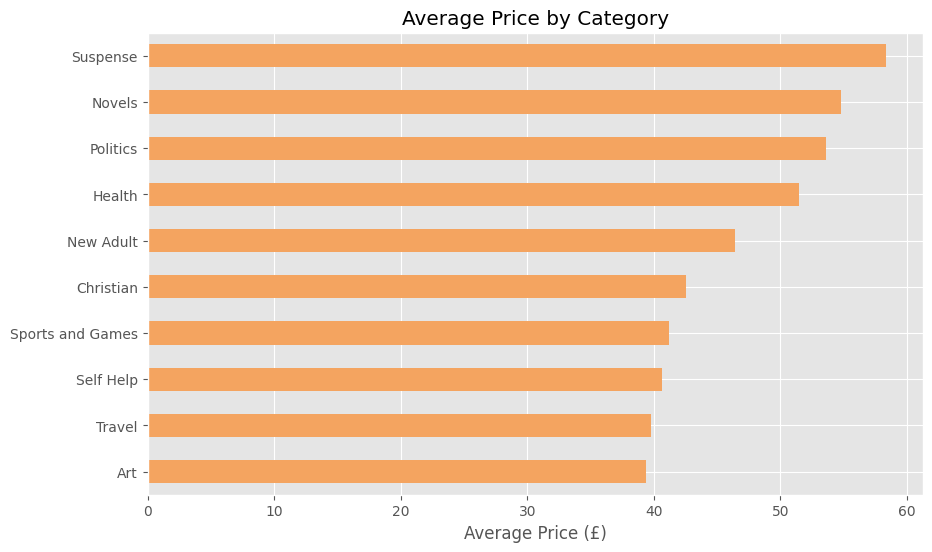

In [52]:
# Visualize average price
plt.figure(figsize=(10,6))

avg_price.sort_values().plot(kind="barh", color="sandybrown")

plt.title("Average Price by Category")

plt.xlabel("Average Price (£)")

plt.ylabel("")

plt.show()

In [53]:
# Stock quantity summary
books_df[
    "stock_quantity"
].describe()

count    992.000000
mean       8.615927
std        5.666004
min        1.000000
25%        3.000000
50%        7.000000
75%       14.000000
max       22.000000
Name: stock_quantity, dtype: float64

In [60]:
books_df["stock_quantity"].value_counts()

stock_quantity
3.0     196
14.0    136
1.0      98
15.0     87
16.0     84
5.0      64
7.0      52
8.0      47
4.0      42
6.0      34
12.0     34
11.0     28
9.0      25
19.0     23
2.0      14
18.0     11
17.0      5
13.0      5
20.0      4
10.0      2
22.0      1
Name: count, dtype: int64

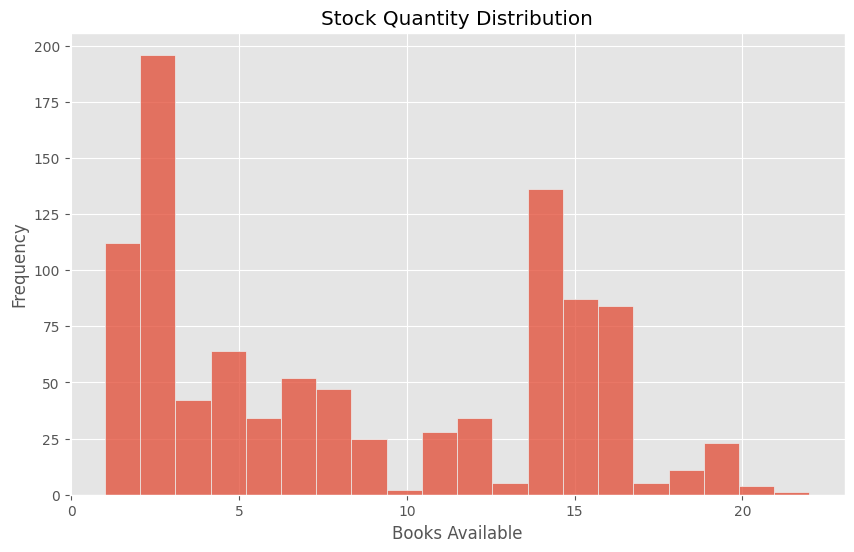

In [62]:
# Stock distribution
plt.figure(figsize=(10,6))

sns.histplot(books_df["stock_quantity"],
    bins=20)

plt.title("Stock Quantity Distribution")

plt.xlabel("Books Available")

plt.ylabel("Frequency")

plt.show()

In [63]:
# Categories with highest stock
stock_category = (
    books_df
    .groupby("category")[
        "stock_quantity"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

stock_category

category
Default           1336.0
Nonfiction         975.0
Sequential Art     682.0
Fiction            588.0
Add a comment      516.0
Young Adult        464.0
Fantasy            364.0
Food and Drink     319.0
Mystery            290.0
Romance            269.0
Name: stock_quantity, dtype: float64

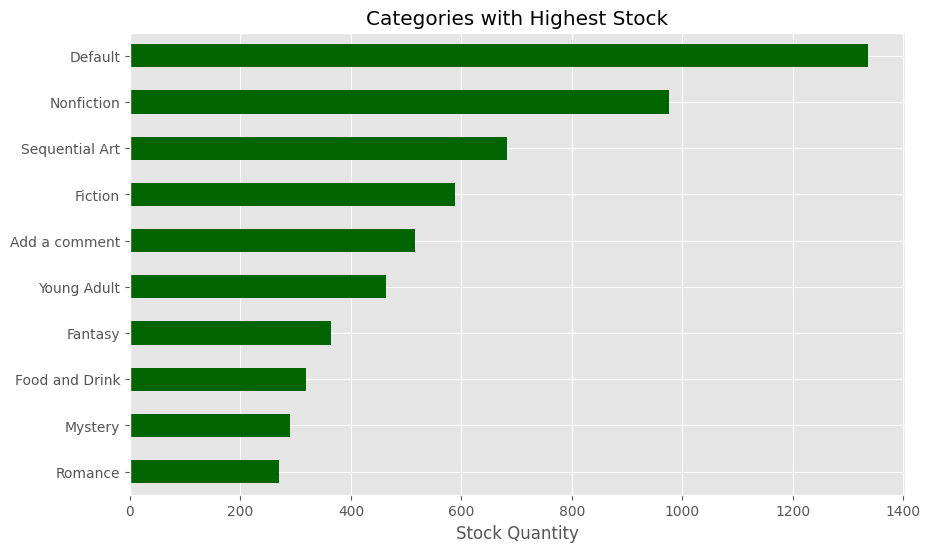

In [69]:
# Visualize stock by category
plt.figure(figsize=(10,6))

stock_category.sort_values().plot(kind="barh", color="darkgreen")

plt.title("Categories with Highest Stock")

plt.xlabel("Stock Quantity")

plt.ylabel("")

plt.show()

In [70]:
# Correlation matrix
books_df[
    [
        "price",
        "rating",
        "stock_quantity"
    ]
].corr()

,price,rating,stock_quantity
price,1.000000,0.028166,-0.009581
rating,0.028166,1.000000,0.017268
stock_quantity,-0.009581,0.017268,1.000000


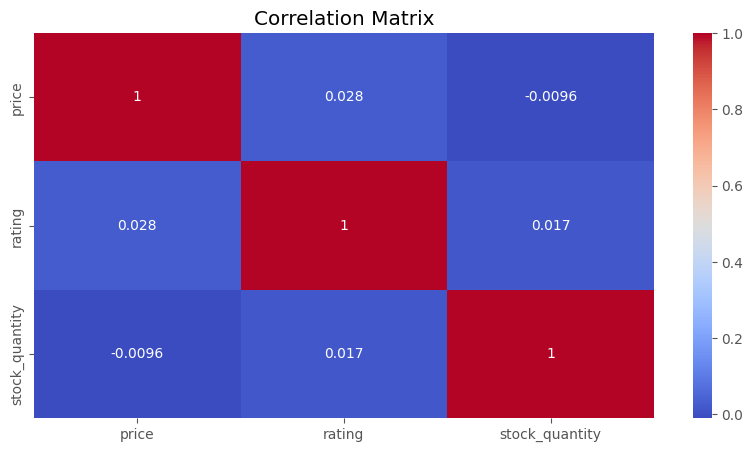

In [76]:
# Correlation heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    books_df[
        [
            "price",
            "rating",
            "stock_quantity"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()